# Análise do Consumo e das Perdas de Energia Elétrica no Brasil

Este notebook apresenta a etapa de exploração, tratamento e preparação dos dados utilizados no dashboard desenvolvido em Power BI.

O objetivo é analisar o consumo e as perdas de energia elétrica no Brasil entre 2004 e 2025, validando os principais indicadores e insights apresentados no dashboard final.

## 1. Importação das bibliotecas e carregamento da base

Nesta etapa eu importei as bibliotecas que iria utilizar no projeto e carreguei a base original para análise.

In [4]:
import pandas as pd

arquivo = "/content/Dados_abertos_Mercado_Distribuicao.xlsx"

abas = pd.ExcelFile(arquivo).sheet_names
abas

['MERCADO DISTRIBUICAO',
 'MERCADO DISTRIBUICAO UF',
 'ANALISE MERCADO DISTRIBUICAO',
 'ANALISE MERCADO DISTRIBUICAO UF']

In [5]:
df_regiao = pd.read_excel(arquivo, sheet_name="MERCADO DISTRIBUICAO")
df_uf = pd.read_excel(arquivo, sheet_name="MERCADO DISTRIBUICAO UF")

print("Base por região:", df_regiao.shape)
print("Base por UF:", df_uf.shape)

Base por região: (1755, 10)
Base por UF: (7685, 11)


## 2. Conhecimento inicial da base

Nesta etapa é realizada uma inspeção inicial da base de dados, verificando sua estrutura, quantidade de registros, tipos das variáveis e qualidade das informações disponíveis.

In [6]:
df_regiao.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1755 entries, 0 to 1754
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Data             1755 non-null   datetime64[ns]
 1   Regiao           1755 non-null   object        
 2   Sistema          1755 non-null   object        
 3   Classe           1755 non-null   object        
 4   TipoConsumidor   1755 non-null   object        
 5   TipoValor        1755 non-null   object        
 6   Consumo_GWh      1755 non-null   float64       
 7   Einj_MMGD_GWh    1755 non-null   float64       
 8   perda_total_GWh  1755 non-null   float64       
 9   DataVersao       1755 non-null   datetime64[ns]
dtypes: datetime64[ns](2), float64(3), object(5)
memory usage: 137.2+ KB


## 3. Exploração inicial dos dados

Após validar a estrutura da base, inicia-se a análise exploratória dos dados (EDA – *Exploratory Data Analysis*). Nesta etapa são analisados o período disponível, as categorias existentes e as principais características do conjunto de dados, permitindo compreender o contexto das informações antes da construção dos indicadores e visualizações.

In [7]:
print("Primeira data:", df_regiao["Data"].min())
print("Última data:", df_regiao["Data"].max())

Primeira data: 2004-12-01 00:00:00
Última data: 2025-12-01 00:00:00


In [8]:
colunas_texto = ["Regiao", "Sistema", "Classe", "TipoConsumidor", "TipoValor"]

for coluna in colunas_texto:
    print(f"\n{'='*50}")
    print(f"Coluna: {coluna}")
    print(df_regiao[coluna].unique())


Coluna: Regiao
['Centro-Oeste' 'Nordeste' 'Norte' 'Sudeste' 'Sul']

Coluna: Sistema
['SISTEMAS ISOLADOS' 'SUDESTE / CENTRO - OESTE' 'NORTE INTERLIGADO' 'SUL'
 'NORDESTE']

Coluna: Classe
['Residencial' 'Industrial' 'Comercial' 'Rural' 'Outros' 'ND']

Coluna: TipoConsumidor
['Cativo' 'Livre' 'ND']

Coluna: TipoValor
['Histórico' 'Projeção SIMPLES2025']


In [9]:
for coluna in colunas_texto:
    print(f"\n{'='*50}")
    print(f"Coluna: {coluna}")
    print(df_regiao[coluna].value_counts())


Coluna: Regiao
Regiao
Nordeste        513
Norte           478
Centro-Oeste    332
Sudeste         222
Sul             210
Name: count, dtype: int64

Coluna: Sistema
Sistema
SUDESTE / CENTRO - OESTE    572
SISTEMAS ISOLADOS           395
NORTE INTERLIGADO           377
SUL                         210
NORDESTE                    201
Name: count, dtype: int64

Coluna: Classe
Classe
Industrial     359
Comercial      356
Outros         302
Rural          298
Residencial    241
ND             199
Name: count, dtype: int64

Coluna: TipoConsumidor
TipoConsumidor
Cativo    1110
Livre      446
ND         199
Name: count, dtype: int64

Coluna: TipoValor
TipoValor
Histórico               1706
Projeção SIMPLES2025      49
Name: count, dtype: int64


In [10]:
df_regiao.describe()

,Data,Consumo_GWh,Einj_MMGD_GWh,perda_total_GWh,DataVersao
count,1755,1755.000000,1.755000e+03,1755.000000,1755
mean,2016-06-15 06:40:24.615384832,5168.566925,8.718424e+01,806.366333,2026-04-29 00:00:00.000000256
min,2004-12-01 00:00:00,0.000000,0.000000e+00,0.000000,2026-04-29 00:00:00
25%,2010-12-01 00:00:00,5.334626,0.000000e+00,0.000000,2026-04-29 00:00:00
50%,2016-12-01 00:00:00,641.568000,0.000000e+00,0.000000,2026-04-29 00:00:00
75%,2021-12-01 00:00:00,4914.669500,1.851599e-07,0.000000,2026-04-29 00:00:00
max,2025-12-01 00:00:00,83391.479686,8.735952e+03,39830.450059,2026-04-29 00:00:00
std,NaN,11555.090632,5.040180e+02,3954.702820,NaN


## 4. Análise da distribuição dos dados

Nesta etapa são utilizadas técnicas de análise visual para compreender a distribuição das variáveis numéricas e identificar possíveis valores discrepantes (*outliers*). Essas verificações auxiliam na interpretação dos dados e garantem maior confiabilidade para as análises desenvolvidas no dashboard.

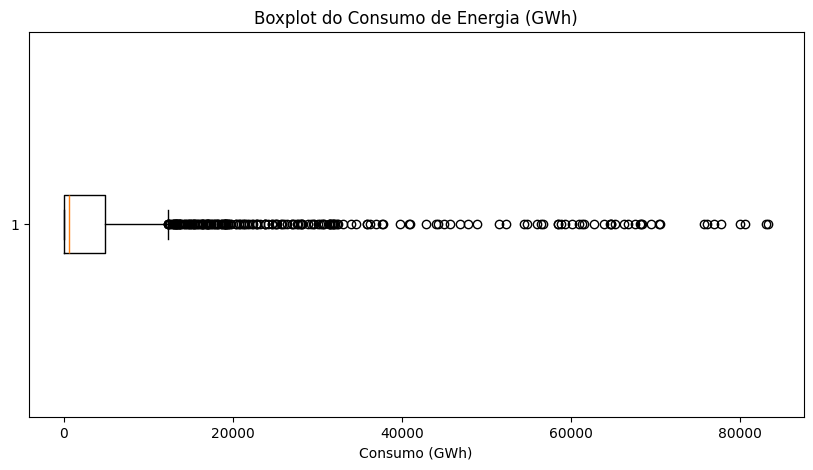

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.boxplot(df_regiao["Consumo_GWh"], vert=False)

plt.title("Boxplot do Consumo de Energia (GWh)")
plt.xlabel("Consumo (GWh)")

plt.show()

In [12]:
df_regiao.sort_values("Consumo_GWh", ascending=False).head(10)

,Data,Regiao,Sistema,Classe,TipoConsumidor,TipoValor,Consumo_GWh,Einj_MMGD_GWh,perda_total_GWh,DataVersao
1003,2025-12-01,Sudeste,SUDESTE / CENTRO - OESTE,Industrial,Livre,Histórico,83391.479686,0.000000,0.0,2026-04-29
998,2024-12-01,Sudeste,SUDESTE / CENTRO - OESTE,Industrial,Livre,Histórico,83054.821112,0.000000,0.0,2026-04-29
418,2025-12-01,Sudeste,SUDESTE / CENTRO - OESTE,Residencial,Cativo,Histórico,80575.955007,0.000000,0.0,2026-04-29
1530,2024-12-01,Sudeste,SUDESTE / CENTRO - OESTE,Residencial,Cativo,Histórico,80061.135807,5292.344247,0.0,2026-04-29
992,2023-12-01,Sudeste,SUDESTE / CENTRO - OESTE,Industrial,Livre,Histórico,77832.809575,0.000000,0.0,2026-04-29
987,2022-12-01,Sudeste,SUDESTE / CENTRO - OESTE,Industrial,Livre,Histórico,76937.927387,0.000000,0.0,2026-04-29
1515,2023-12-01,Sudeste,SUDESTE / CENTRO - OESTE,Residencial,Cativo,Histórico,76170.106883,4006.559431,0.0,2026-04-29
982,2021-12-01,Sudeste,SUDESTE / CENTRO - OESTE,Industrial,Livre,Histórico,75764.245842,0.000000,0.0,2026-04-29
1490,2021-12-01,Sudeste,SUDESTE / CENTRO - OESTE,Residencial,Cativo,Histórico,70554.041358,1053.849979,0.0,2026-04-29
1500,2022-12-01,Sudeste,SUDESTE / CENTRO - OESTE,Residencial,Cativo,Histórico,70469.862619,2188.142225,0.0,2026-04-29


In [13]:
df_regiao.groupby(["Regiao", "Classe"])["Consumo_GWh"].sum().sort_values(ascending=False).head(10)

Regiao    Classe     
Sudeste   Industrial     1.883550e+06
          Residencial    1.374746e+06
          Comercial      9.459724e+05
Sul       Industrial     6.340585e+05
Nordeste  Residencial    5.367819e+05
Sul       Residencial    4.491086e+05
Sudeste   Outros         4.394486e+05
Nordeste  Industrial     3.086384e+05
Sul       Comercial      3.036338e+05
Nordeste  Comercial      2.692798e+05
Name: Consumo_GWh, dtype: float64

## 5. Tratamento e preparação dos dados

Nesta etapa foram realizadas as transformações necessárias para preparar a base de dados utilizada nas análises e na construção do dashboard. São criadas novas variáveis, ajustados formatos e organizadas as informações para facilitar a geração dos indicadores e visualizações.

In [14]:
df_regiao["Ano"] = df_regiao["Data"].dt.year

df_regiao[["Data", "Ano"]].head()

,Data,Ano
0,2004-12-01,2004
1,2004-12-01,2004
2,2004-12-01,2004
3,2004-12-01,2004
4,2004-12-01,2004


In [15]:
consumo_por_ano = (
    df_regiao
    .groupby("Ano")["Consumo_GWh"]
    .sum()
)

consumo_por_ano

,Consumo_GWh
Ano,
2004,297134.519547
2005,310576.215661
2006,320342.972465
2007,338632.371000
2008,349646.973890
2009,347682.103000
2010,376887.601665
2011,392434.784857
2012,406429.115767


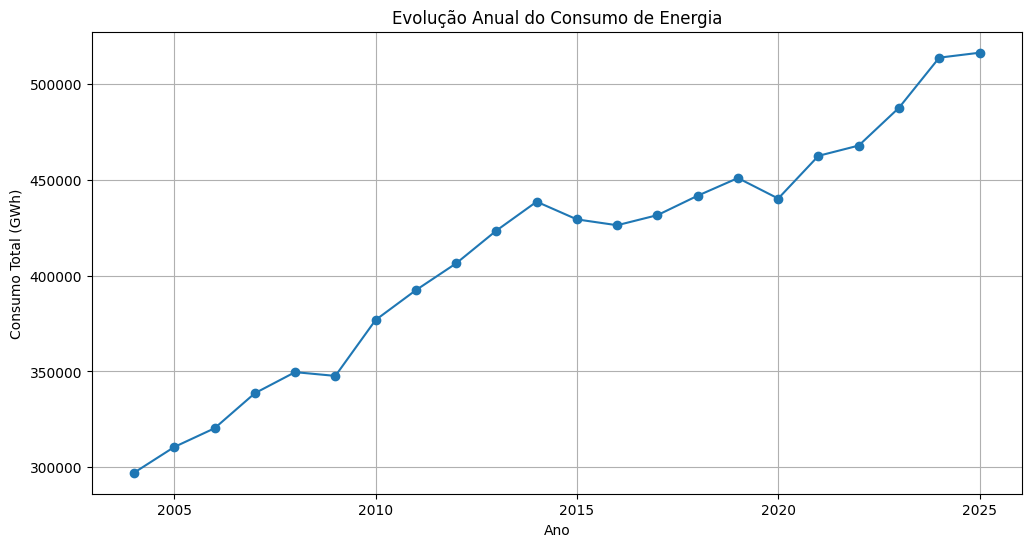

In [16]:
plt.figure(figsize=(12,6))

plt.plot(consumo_por_ano.index, consumo_por_ano.values, marker="o")

plt.title("Evolução Anual do Consumo de Energia")
plt.xlabel("Ano")
plt.ylabel("Consumo Total (GWh)")
plt.grid(True)

plt.show()

In [17]:
consumo_por_classe = (
    df_regiao
    .groupby("Classe")["Consumo_GWh"]
    .sum()
    .sort_values(ascending=False)
)

consumo_por_classe

,Consumo_GWh
Classe,
Industrial,3.066379e+06
Residencial,2.777042e+06
Comercial,1.756023e+06
Outros,9.304852e+05
Rural,5.409056e+05
ND,0.000000e+00


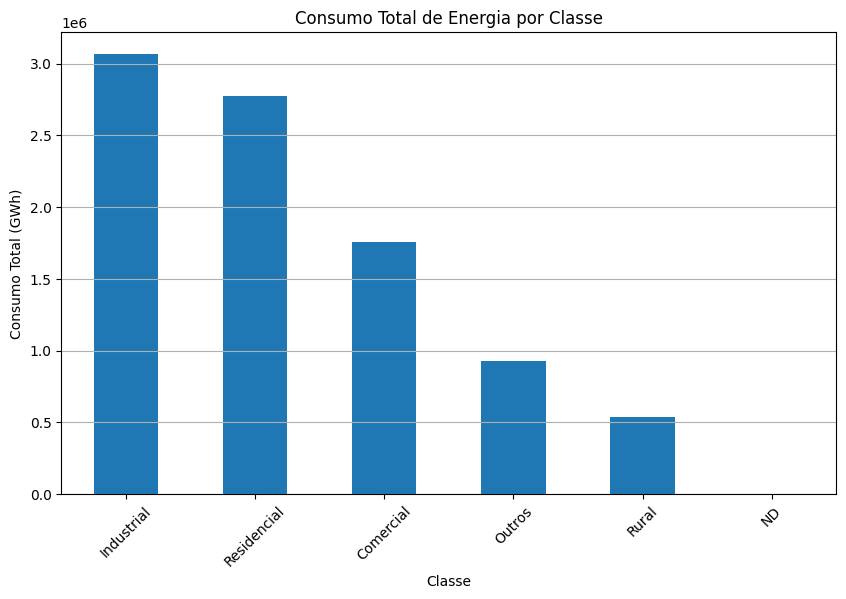

In [18]:
plt.figure(figsize=(10,6))

consumo_por_classe.plot(kind="bar")

plt.title("Consumo Total de Energia por Classe")
plt.xlabel("Classe")
plt.ylabel("Consumo Total (GWh)")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

In [19]:
consumo_ano_classe = (
    df_regiao
    .groupby(["Ano", "Classe"])["Consumo_GWh"]
    .sum()
    .reset_index()
)

consumo_ano_classe.head(10)

,Ano,Classe,Consumo_GWh
0,2004,Comercial,49674.307223
1,2004,Industrial,122879.467446
2,2004,Outros,31595.602364
3,2004,Residencial,78462.680052
4,2004,Rural,14522.462462
5,2005,Comercial,53028.019716
6,2005,Industrial,126260.438460
7,2005,Outros,33076.672866
8,2005,Residencial,82632.447215
9,2005,Rural,15578.637404


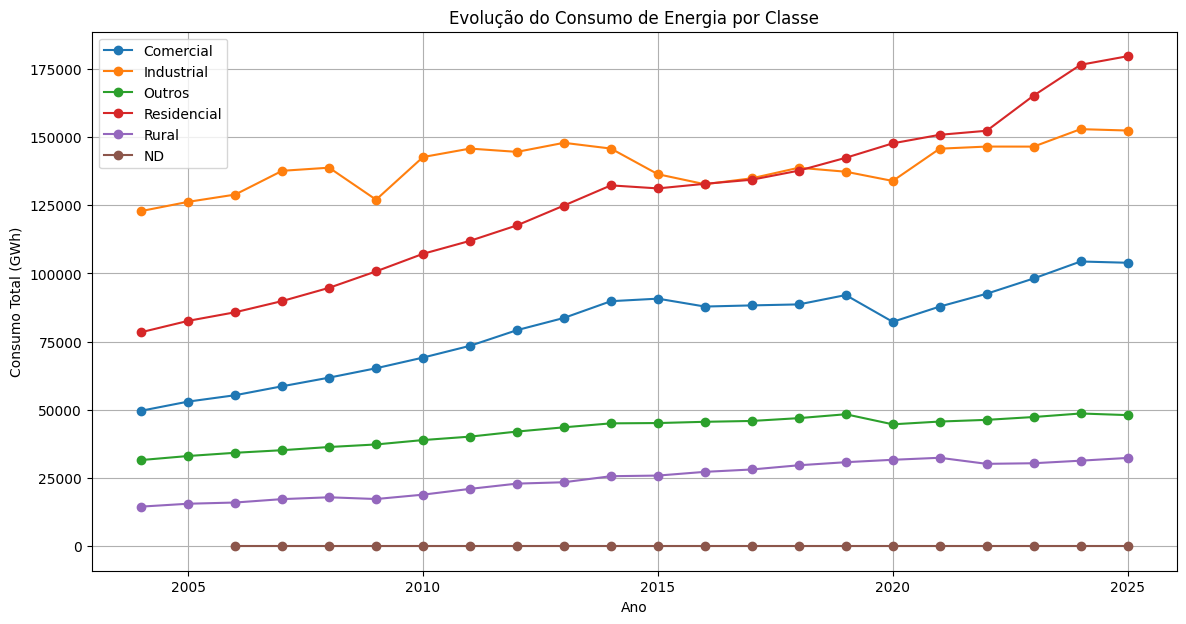

In [20]:
plt.figure(figsize=(14,7))

for classe in consumo_ano_classe["Classe"].unique():
    dados_classe = consumo_ano_classe[consumo_ano_classe["Classe"] == classe]
    plt.plot(dados_classe["Ano"], dados_classe["Consumo_GWh"], marker="o", label=classe)

plt.title("Evolução do Consumo de Energia por Classe")
plt.xlabel("Ano")
plt.ylabel("Consumo Total (GWh)")
plt.legend()
plt.grid(True)

plt.show()

In [21]:
consumo_ano_classe_regiao = (
    df_regiao
    .groupby(["Ano", "Classe", "Regiao"])["Consumo_GWh"]
    .sum()
    .reset_index()
)

consumo_ano_classe_regiao.head()

,Ano,Classe,Regiao,Consumo_GWh
0,2004,Comercial,Centro-Oeste,3672.297010
1,2004,Comercial,Nordeste,6953.625268
2,2004,Comercial,Norte,2342.708211
3,2004,Comercial,Sudeste,28449.002229
4,2004,Comercial,Sul,8256.674505


In [22]:
residencial_por_regiao = (
    consumo_ano_classe_regiao
    [consumo_ano_classe_regiao["Classe"] == "Residencial"]
    .groupby("Regiao")["Consumo_GWh"]
    .sum()
    .sort_values(ascending=False)
)

residencial_por_regiao

,Consumo_GWh
Regiao,
Sudeste,1.374746e+06
Nordeste,5.367819e+05
Sul,4.491086e+05
Centro-Oeste,2.339263e+05
Norte,1.824790e+05


In [23]:
residencial_evolucao_regiao = (
    consumo_ano_classe_regiao
    [consumo_ano_classe_regiao["Classe"] == "Residencial"]
    .pivot(index="Ano", columns="Regiao", values="Consumo_GWh")
)

residencial_evolucao_regiao

Regiao,Centro-Oeste,Nordeste,Norte,Sudeste,Sul
Ano,,,,,
2004,5950.160257,12488.068062,4078.813921,42833.144445,13112.493367
2005,6289.008387,13392.688763,4285.606071,44991.169283,13673.974711
2006,6501.979261,13975.761676,4400.619106,46852.367839,14046.705513
2007,6770.528000,14677.284000,4625.559000,48870.379000,14935.194000
2008,7096.152000,15779.318737,4962.960000,51477.192000,15424.300000
2009,7573.182000,17220.495000,5250.058000,54415.448000,16310.177000
2010,8206.366000,19284.264000,5915.258000,56680.348000,17121.123000
2011,8525.064000,20162.539000,6186.679000,59348.680000,17740.158000
2012,9202.311000,21395.101000,6756.151000,61594.523000,18689.752525


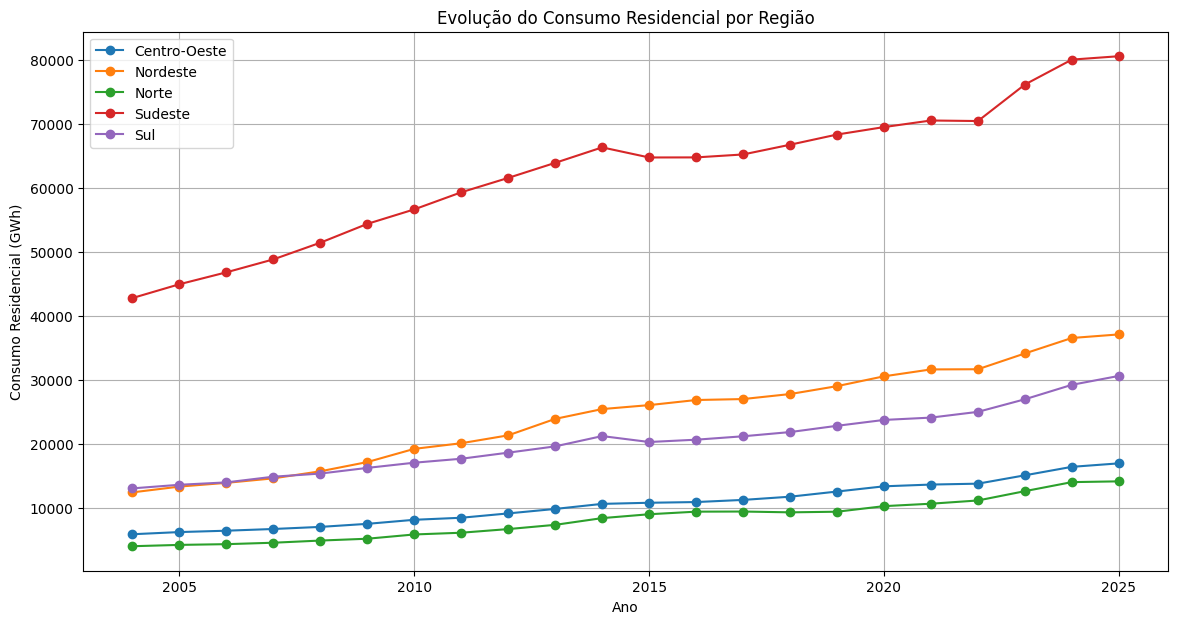

In [24]:
plt.figure(figsize=(14,7))

for regiao in residencial_evolucao_regiao.columns:
    plt.plot(
        residencial_evolucao_regiao.index,
        residencial_evolucao_regiao[regiao],
        marker="o",
        label=regiao
    )

plt.title("Evolução do Consumo Residencial por Região")
plt.xlabel("Ano")
plt.ylabel("Consumo Residencial (GWh)")
plt.legend()
plt.grid(True)

plt.show()

In [25]:
comparativo = residencial_evolucao_regiao.loc[[2004, 2025]]

comparativo

Regiao,Centro-Oeste,Nordeste,Norte,Sudeste,Sul
Ano,,,,,
2004,5950.160257,12488.068062,4078.813921,42833.144445,13112.493367
2025,17018.432021,37153.389227,14209.402235,80595.546070,30671.536790


In [26]:
crescimento_regiao = pd.DataFrame({
    "Consumo_2004": comparativo.loc[2004],
    "Consumo_2025": comparativo.loc[2025]
})

crescimento_regiao["Crescimento_Absoluto_GWh"] = (
    crescimento_regiao["Consumo_2025"] - crescimento_regiao["Consumo_2004"]
)

crescimento_regiao["Crescimento_Percentual"] = (
    crescimento_regiao["Crescimento_Absoluto_GWh"] / crescimento_regiao["Consumo_2004"]
) * 100

crescimento_regiao.sort_values("Crescimento_Absoluto_GWh", ascending=False)

,Consumo_2004,Consumo_2025,Crescimento_Absoluto_GWh,Crescimento_Percentual
Regiao,,,,
Sudeste,42833.144445,80595.546070,37762.401625,88.161638
Nordeste,12488.068062,37153.389227,24665.321165,197.511105
Sul,13112.493367,30671.536790,17559.043423,133.910790
Centro-Oeste,5950.160257,17018.432021,11068.271764,186.016364
Norte,4078.813921,14209.402235,10130.588314,248.370936


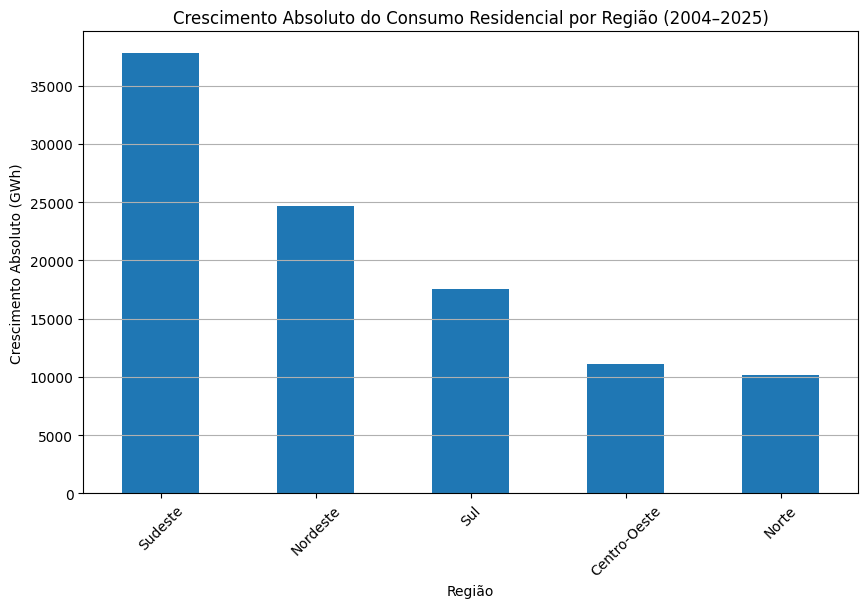

In [27]:
plt.figure(figsize=(10,6))

crescimento_regiao["Crescimento_Absoluto_GWh"].sort_values(ascending=False).plot(kind="bar")

plt.title("Crescimento Absoluto do Consumo Residencial por Região (2004–2025)")
plt.xlabel("Região")
plt.ylabel("Crescimento Absoluto (GWh)")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

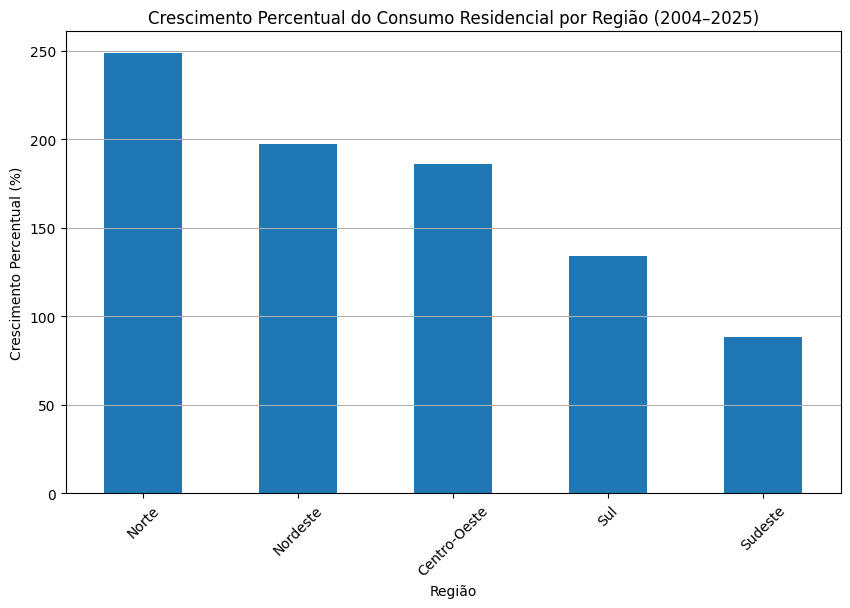

In [28]:
plt.figure(figsize=(10,6))

crescimento_regiao["Crescimento_Percentual"].sort_values(ascending=False).plot(kind="bar")

plt.title("Crescimento Percentual do Consumo Residencial por Região (2004–2025)")
plt.xlabel("Região")
plt.ylabel("Crescimento Percentual (%)")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

In [29]:
perda_por_regiao = (
    df_regiao
    .groupby("Regiao")["perda_total_GWh"]
    .sum()
    .sort_values(ascending=False)
)

perda_por_regiao

,perda_total_GWh
Regiao,
Sudeste,663616.759212
Nordeste,264988.147272
Norte,204321.447320
Sul,177613.769580
Centro-Oeste,104632.790438


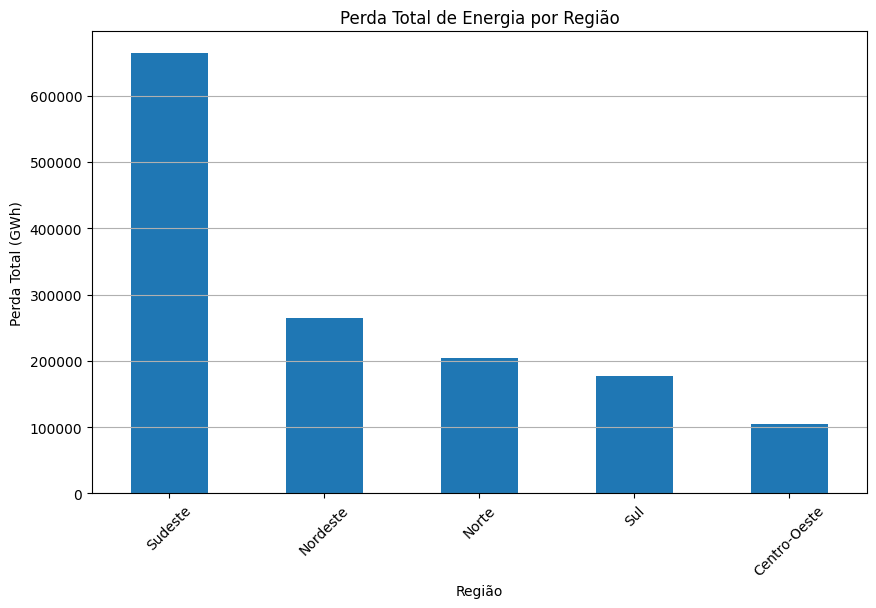

In [30]:
plt.figure(figsize=(10,6))

perda_por_regiao.plot(kind="bar")

plt.title("Perda Total de Energia por Região")
plt.xlabel("Região")
plt.ylabel("Perda Total (GWh)")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

In [31]:
resumo_regiao = (
    df_regiao
    .groupby("Regiao")[["Consumo_GWh", "perda_total_GWh"]]
    .sum()
)

resumo_regiao["Taxa_Perde_%"] = (
    resumo_regiao["perda_total_GWh"] / resumo_regiao["Consumo_GWh"]
) * 100

resumo_regiao.sort_values("Taxa_Perde_%", ascending=False)

,Consumo_GWh,perda_total_GWh,Taxa_Perde_%
Regiao,,,
Norte,4.554829e+05,204321.447320,44.858200
Nordeste,1.423016e+06,264988.147272,18.621585
Centro-Oeste,6.807336e+05,104632.790438,15.370594
Sudeste,4.813939e+06,663616.759212,13.785318
Sul,1.697664e+06,177613.769580,10.462248


In [32]:
kpi_regiao = resumo_regiao.copy()

kpi_regiao = kpi_regiao.rename(columns={
    "Consumo_GWh": "Consumo_Total_GWh",
    "perda_total_GWh": "Perda_Total_GWh",
    "Taxa_Perde_%": "Taxa_Perda_%"
})

kpi_regiao = kpi_regiao.sort_values("Taxa_Perda_%", ascending=False)

kpi_regiao

,Consumo_Total_GWh,Perda_Total_GWh,Taxa_Perda_%
Regiao,,,
Norte,4.554829e+05,204321.447320,44.858200
Nordeste,1.423016e+06,264988.147272,18.621585
Centro-Oeste,6.807336e+05,104632.790438,15.370594
Sudeste,4.813939e+06,663616.759212,13.785318
Sul,1.697664e+06,177613.769580,10.462248


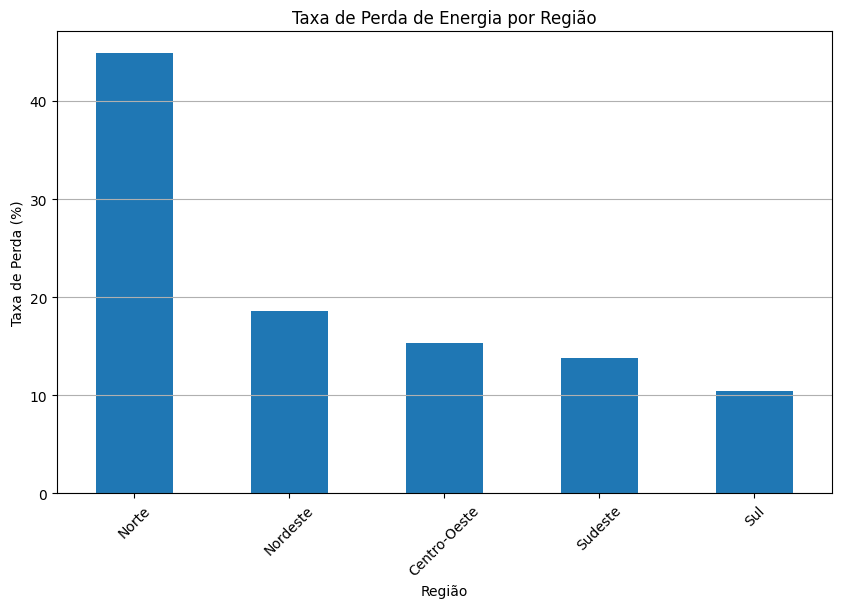

In [33]:
plt.figure(figsize=(10,6))

kpi_regiao["Taxa_Perda_%"].plot(kind="bar")

plt.title("Taxa de Perda de Energia por Região")
plt.xlabel("Região")
plt.ylabel("Taxa de Perda (%)")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

## 6. Construção e exportação da base final

Nesta etapa foi criada a base final utilizada no Power BI. As colunas foram renomeadas para facilitar a leitura no dashboard, a taxa de perda é calculada e o arquivo final é exportado em formato CSV para ser utilizado na construção do relatório.

In [34]:
base_dashboard = df_regiao.copy()

base_dashboard = base_dashboard.rename(columns={
    "Consumo_GWh": "Consumo_Total_GWh",
    "perda_total_GWh": "Perda_Total_GWh",
    "Einj_MMGD_GWh": "Energia_Injetada_MMGD_GWh"
})

base_dashboard["Taxa_Perda_%"] = (
    base_dashboard["Perda_Total_GWh"] / base_dashboard["Consumo_Total_GWh"]
) * 100

base_dashboard.head()

,Data,Regiao,Sistema,Classe,TipoConsumidor,TipoValor,Consumo_Total_GWh,Energia_Injetada_MMGD_GWh,Perda_Total_GWh,DataVersao,Ano,Taxa_Perda_%
0,2004-12-01,Centro-Oeste,SISTEMAS ISOLADOS,Residencial,Cativo,Histórico,103.020935,0.0,0.0,2026-04-29,2004,0.0
1,2004-12-01,Centro-Oeste,SISTEMAS ISOLADOS,Industrial,Cativo,Histórico,58.585353,0.0,0.0,2026-04-29,2004,0.0
2,2004-12-01,Centro-Oeste,SISTEMAS ISOLADOS,Comercial,Cativo,Histórico,62.873250,0.0,0.0,2026-04-29,2004,0.0
3,2004-12-01,Centro-Oeste,SISTEMAS ISOLADOS,Rural,Cativo,Histórico,31.163492,0.0,0.0,2026-04-29,2004,0.0
4,2004-12-01,Centro-Oeste,SISTEMAS ISOLADOS,Outros,Cativo,Histórico,38.103785,0.0,0.0,2026-04-29,2004,0.0
